# Phase 5 CRISP-DM — Evaluation
## Consolidating Results and Business Recommendations

**Project:** Customer Behavior Analysis — Olist Brazilian E-Commerce
**Goal:** Validate the coherence of all models and analyses, and translate the technical
findings into actionable business recommendations.

This notebook consolidates the results of the previous phases:
| Phase | Notebook | Main result |
|------|----------|--------------------|
| 2 — Data Understanding | `01_eda.ipynb` | Full EDA: quality, distributions, trends |
| 3 — Data Preparation | `02_data_prep.ipynb` | `olist_master.csv`: 96,457 orders, 18 variables |
| 4 — Modeling (reviews) | `03_negative_reviews.ipynb` | Top 3 negative-review drivers |
| 4 — Modeling (RFM) | `04_rfm_segmentation.ipynb` | 6 customer segments, 93,337 customers |

---


## 0. Imports and configuration

In [1]:
import sqlite3
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

ROOT    = Path().resolve().parent
DB_PATH = ROOT / "data" / "olist.db"
MASTER  = ROOT / "data" / "olist_master.csv"
RFM_CSV = ROOT / "data" / "olist_rfm.csv"
DASH    = ROOT / "dashboard"

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.float_format", "{:.2f}".format)

SEG_COLORS = {
    "Champions":     "#1a9850",
    "Loyal":         "#91cf60",
    "New Customers": "#4393c3",
    "At Risk":       "#fc8d59",
    "Lost":          "#d73027",
    "Others":        "#aaaaaa",
}

for p in [MASTER, RFM_CSV, DB_PATH]:
    print(f"{'OK' if p.exists() else 'MISSING':>7}  {p.name}")

     OK  olist_master.csv
     OK  olist_rfm.csv
     OK  olist.db


---
## 1. Data loading

In [2]:
master = pd.read_csv(MASTER, parse_dates=["order_purchase_timestamp"])
rfm    = pd.read_csv(RFM_CSV)

# Subset with a review, for satisfaction analysis
master_rev = master.dropna(subset=["review_score"]).copy()
master_rev["review_score"]       = master_rev["review_score"].astype(int)
master_rev["is_negative_review"] = (master_rev["review_score"] <= 2).astype(int)

# Retention by category from SQLite
conn = sqlite3.connect(DB_PATH)
retention_sql = (ROOT / "sql" / "03_retention.sql").read_text(encoding="utf-8")
retention_df  = pd.read_sql(retention_sql, conn)
conn.close()

print(f"master:       {master.shape}")
print(f"master_rev:   {master_rev.shape}  (with review)")
print(f"rfm:          {rfm.shape}")
print(f"retention:    {retention_df.shape}  (categories ranked by retention)")

master:       (96457, 20)
master_rev:   (95811, 20)  (with review)
rfm:          (93337, 10)
retention:    (58, 9)  (categories ranked by retention)


---
## 2. RFM segment evaluation

### 2.1 Summary table: average R, F, M by segment
We check that each segment has a behavior profile consistent with its definition.
A valid segment should be distinguishable from the others in at least one key dimension.

In [3]:
seg_order = ["Champions", "Loyal", "New Customers", "At Risk", "Lost", "Others"]

seg_summary = (
    rfm.groupby("segment", as_index=False)
    .agg(
        n_customers      =("customer_unique_id", "count"),
        pct_customers    =("customer_unique_id", lambda x: len(x) / len(rfm) * 100),
        avg_recency      =("recency",            "mean"),
        med_recency      =("recency",            "median"),
        avg_frequency    =("frequency",           "mean"),
        avg_monetary     =("monetary",            "mean"),
        med_monetary     =("monetary",            "median"),
        total_revenue    =("monetary",            "sum"),
        pct_revenue      =("monetary",            lambda x: x.sum() / rfm["monetary"].sum() * 100),
        avg_R            =("R_score",             "mean"),
        avg_F            =("F_score",             "mean"),
        avg_M            =("M_score",             "mean"),
        avg_RFM_score    =("RFM_score",           "mean"),
    )
)

# Order according to the defined seg_order
seg_summary["order"] = seg_summary["segment"].map({s: i for i, s in enumerate(seg_order)})
seg_summary = seg_summary.sort_values("order").drop(columns="order").reset_index(drop=True)

display_cols = [
    "segment", "n_customers", "pct_customers",
    "avg_recency", "avg_frequency", "avg_monetary",
    "pct_revenue", "avg_R", "avg_F", "avg_M", "avg_RFM_score",
]
display(
    seg_summary[display_cols]
    .rename(columns={
        "segment": "Segment", "n_customers": "Customers",
        "pct_customers": "% customers", "avg_recency": "Recency (days)",
        "avg_frequency": "Frequency", "avg_monetary": "Monetary (BRL)",
        "pct_revenue": "% revenue", "avg_R": "R_score",
        "avg_F": "F_score", "avg_M": "M_score", "avg_RFM_score": "RFM_score",
    })
    .set_index("Segment")
    .round(2)
    .style
    .background_gradient(subset=["R_score", "F_score", "M_score", "RFM_score"], cmap="RdYlGn")
    .format({
        "Customers": "{:,.0f}", "% customers": "{:.1f}%",
        "Recency (days)": "{:.0f}", "Frequency": "{:.2f}",
        "Monetary (BRL)": "R${:.1f}", "% revenue": "{:.1f}%",
    })
)

,Customers,% customers,Recency (days),Frequency,Monetary (BRL),% revenue,R_score,F_score,M_score,RFM_score
Segment,,,,,,,,,,
Champions,121,0.1%,89,3.51,R$461.5,0.4%,4.500000,5.000000,4.700000,4.730000
Loyal,"1,689",1.8%,135,2.03,R$253.5,3.2%,3.970000,3.040000,4.170000,3.730000
New Customers,"36,132",38.7%,90,1.00,R$140.3,38.4%,4.500000,1.000000,2.990000,2.830000
At Risk,991,1.1%,382,2.08,R$246.6,1.9%,1.560000,3.140000,4.050000,2.920000
Lost,"36,344",38.9%,395,1.00,R$139.6,38.4%,1.500000,1.000000,2.950000,1.820000
Others,"18,060",19.4%,220,1.00,R$129.9,17.8%,3.000000,1.000000,2.950000,2.320000


### 2.2 Segment coherence validation
We check that each segment's average R, F, M scores match the business logic defined in notebook 04.

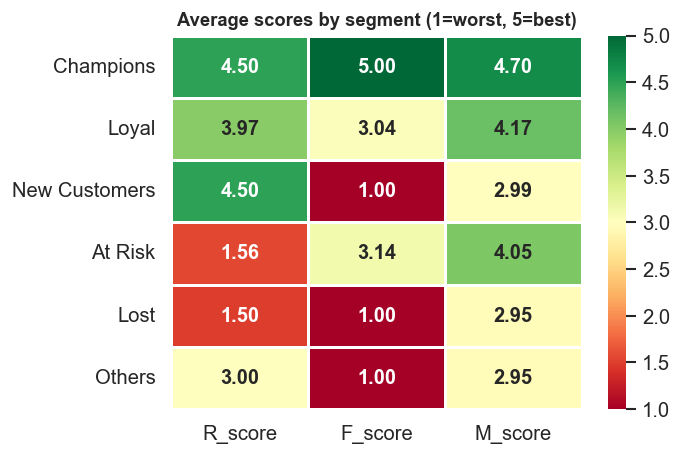

In [4]:
# Heatmap of average scores by segment
score_pivot = seg_summary.set_index("segment")[["avg_R", "avg_F", "avg_M"]].loc[
    [s for s in seg_order if s in seg_summary["segment"].values]
]
score_pivot.columns = ["R_score", "F_score", "M_score"]

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    score_pivot, annot=True, fmt=".2f",
    cmap="RdYlGn", vmin=1, vmax=5,
    linewidths=0.8, ax=ax,
    annot_kws={"size": 12, "weight": "bold"},
)
ax.set_title("Average scores by segment (1=worst, 5=best)",
             fontsize=11, fontweight="bold")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(DASH / "eval_rfm_scores_heatmap.png", bbox_inches="tight")
plt.show()

**Fix (portfolio review, priority 1):** the 4 checks in an earlier version of this
notebook were **tautological**: they compared `R_score`/`F_score` between segments that are
DEFINED by thresholds on those same scores (Champions = R≥4∧F≥4, Lost = R≤2∧F≤2, ...) -- they
cannot fail short of a code bug in `assign_segment`, and they didn't test anything against real
observed behavior. They are replaced with **falsifiable** checks on variables `assign_segment`
NEVER uses to decide the segment: `monetary` (M_score doesn't enter the assignment rule) and
observed `frequency`. If the segmentation were noise (as was the case before fixing F_score, see
notebook 04 §3), these would have no reason to hold.

In [5]:
obs = rfm.groupby("segment").agg(
    avg_monetary=("monetary", "mean"), avg_frequency=("frequency", "mean"),
)
print("\nSegment coherence validation (falsifiable checks, not tautological):")
checks = [
    ("Champions has higher average Monetary than Lost (M_score doesn't define the segment)",
     obs.loc["Champions", "avg_monetary"] > obs.loc["Lost", "avg_monetary"]),
    ("Loyal has higher average Monetary than New Customers (M_score doesn't define the segment)",
     obs.loc["Loyal", "avg_monetary"] > obs.loc["New Customers", "avg_monetary"]),
    ("At Risk has real observed Frequency higher than Lost "
     "(both with R<=2; if it were noise, they'd be indistinguishable as before the fix)",
     obs.loc["At Risk", "avg_frequency"] > obs.loc["Lost", "avg_frequency"]),
    ("Champions has observed Frequency higher than New Customers",
     obs.loc["Champions", "avg_frequency"] > obs.loc["New Customers", "avg_frequency"]),
]
all_ok = True
for desc, result in checks:
    icon = "PASS" if result else "FAIL"
    print(f"  [{icon}] {desc}")
    if not result:
        all_ok = False
print(f"\n  Result: {'All checks passed (segmentation discriminates real behavior)' if all_ok else 'Review segmentation'}")
print(f"\n  Reference -- Average Monetary: Champions={obs.loc['Champions','avg_monetary']:.0f}, "
      f"Loyal={obs.loc['Loyal','avg_monetary']:.0f}, At Risk={obs.loc['At Risk','avg_monetary']:.0f}, "
      f"New Customers={obs.loc['New Customers','avg_monetary']:.0f}, Lost={obs.loc['Lost','avg_monetary']:.0f}")
print(f"  Reference -- Average Frequency: At Risk={obs.loc['At Risk','avg_frequency']:.2f}, "
      f"Lost={obs.loc['Lost','avg_frequency']:.2f} (before the fix both were ~1.0-1.05, "
      f"indistinguishable)")


Segment coherence validation (falsifiable checks, not tautological):
  [PASS] Champions has higher average Monetary than Lost (M_score doesn't define the segment)
  [PASS] Loyal has higher average Monetary than New Customers (M_score doesn't define the segment)
  [PASS] At Risk has real observed Frequency higher than Lost (both with R<=2; if it were noise, they'd be indistinguishable as before the fix)
  [PASS] Champions has observed Frequency higher than New Customers

  Result: All checks passed (segmentation discriminates real behavior)

  Reference -- Average Monetary: Champions=462, Loyal=254, At Risk=247, New Customers=140, Lost=140
  Reference -- Average Frequency: At Risk=2.08, Lost=1.00 (before the fix both were ~1.0-1.05, indistinguishable)


### 2.3 Profile of each segment
Business description of each group based on the real data.

In [6]:
profiles = {
    "Champions": (
        "Bought recently and with the highest frequency in the dataset. "
        "They are the most valuable segment in average monetary terms. "
        "Action: VIP program, early access, active referrals."
    ),
    "Loyal": (
        "Recurring customers with moderate recency. Good frequency and spend. "
        "They represent the stable base of the business. "
        "Action: upsell to premium categories, volume discounts."
    ),
    "New Customers": (
        "Bought recently but only once. High potential for retention. "
        "High recency indicates the relationship is still alive. "
        "Action: onboarding email, discount on second purchase, personalized recommendations."
    ),
    "At Risk": (
        "Customers who DID repeat purchase (frequency>=2, verified in Section 2.2 -- no longer "
        "noise) but haven't bought in a long time. A small but genuine group (~1% of the "
        "base) that has already shown willingness to buy again. "
        "Action: targeted win-back campaign with a time-limited coupon."
    ),
    "Lost": (
        "Bought only once and haven't come back in a long time (frequency=1, low R). It's the "
        "largest segment in the dataset along with New Customers (~39% each) -- reflecting "
        "Olist's structurally low repurchase rate (~3%), not a segmentation anomaly. "
        "Action: low-cost campaigns; don't prioritize over At Risk, which does have a repurchase history."
    ),
    "Others": (
        "Intermediate score combinations that don't fit the main segments. "
        "They need continuous monitoring and reclassification in the next RFM iteration."
    ),
}

print("RFM SEGMENT PROFILES — OLIST\n" + "=" * 65)
for seg in seg_order:
    row = seg_summary[seg_summary["segment"] == seg]
    if row.empty:
        continue
    row = row.iloc[0]
    print(f"\n[{seg.upper()}]")
    print(f"  Customers:       {int(row['n_customers']):,} ({row['pct_customers']:.1f}%)")
    print(f"  Average recency: {row['avg_recency']:.0f} days")
    print(f"  Average frequency: {row['avg_frequency']:.2f} orders")
    print(f"  Average monetary:  R${row['avg_monetary']:.0f}")
    print(f"  RFM score:       {row['avg_RFM_score']:.2f}/5")
    print(f"  Profile:         {profiles.get(seg, '')}")

RFM SEGMENT PROFILES — OLIST

[CHAMPIONS]
  Customers:       121 (0.1%)
  Average recency: 89 days
  Average frequency: 3.51 orders
  Average monetary:  R$462
  RFM score:       4.73/5
  Profile:         Bought recently and with the highest frequency in the dataset. They are the most valuable segment in average monetary terms. Action: VIP program, early access, active referrals.

[LOYAL]
  Customers:       1,689 (1.8%)
  Average recency: 135 days
  Average frequency: 2.03 orders
  Average monetary:  R$254
  RFM score:       3.73/5
  Profile:         Recurring customers with moderate recency. Good frequency and spend. They represent the stable base of the business. Action: upsell to premium categories, volume discounts.

[NEW CUSTOMERS]
  Customers:       36,132 (38.7%)
  Average recency: 90 days
  Average frequency: 1.00 orders
  Average monetary:  R$140
  RFM score:       2.83/5
  Profile:         Bought recently but only once. High potential for retention. High recency indicates the 

### 2.4 Comparative segment visualization — Radar chart
The radar chart lets us compare each segment's three scores simultaneously,
visually confirming that the segments have differentiated profiles.

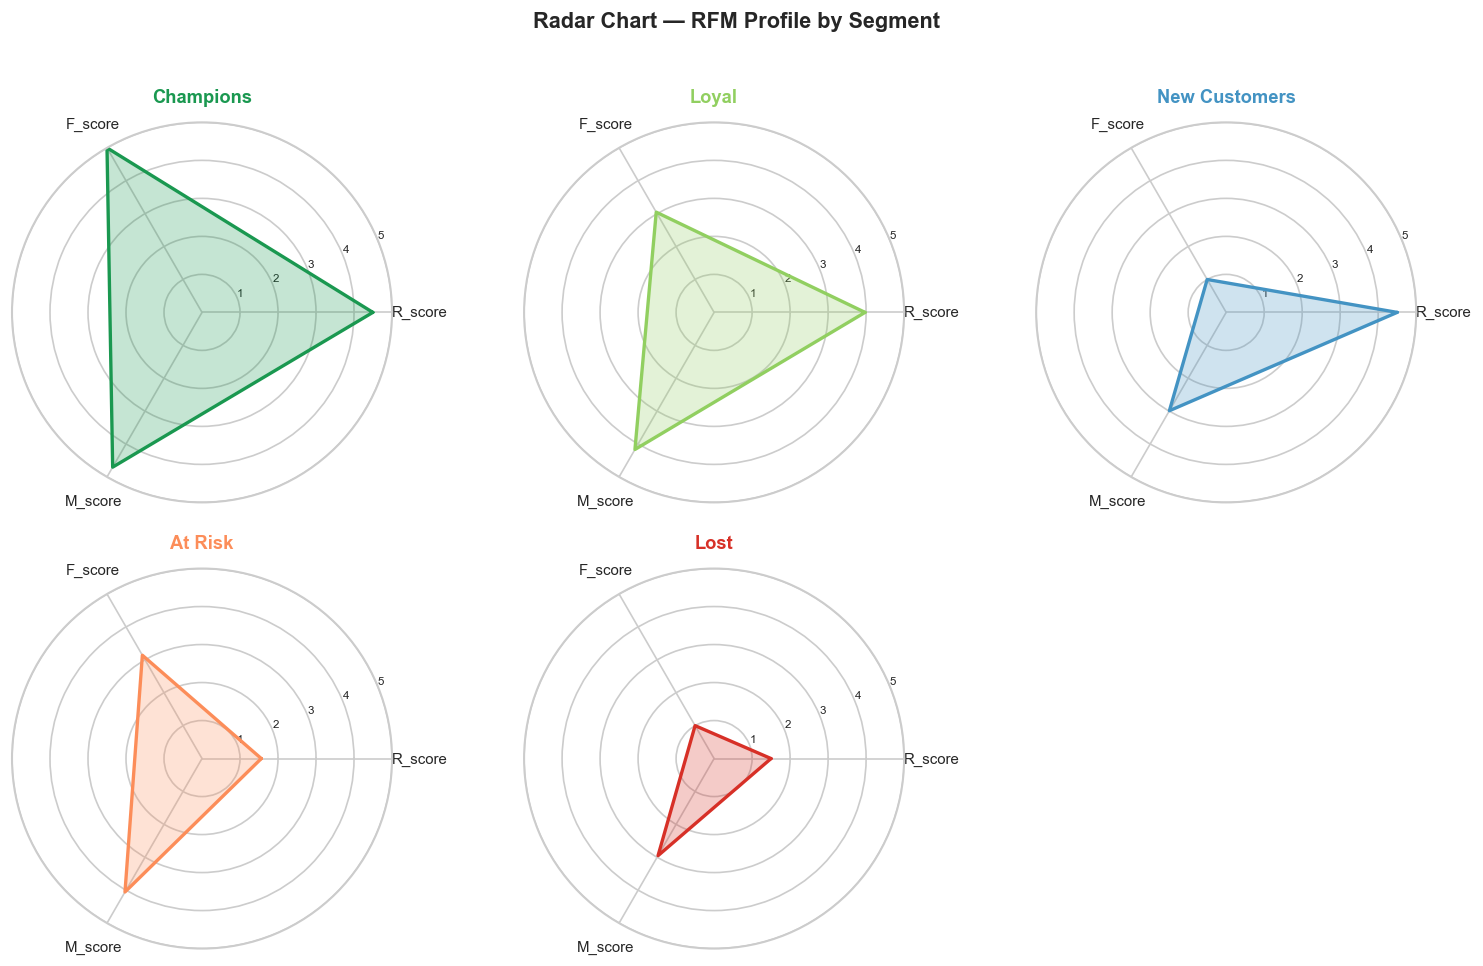

In [7]:
radar_segs = [s for s in seg_order if s != "Others"]
labels     = ["R_score", "F_score", "M_score"]
n_vars     = len(labels)
angles     = np.linspace(0, 2 * np.pi, n_vars, endpoint=False).tolist()
angles    += angles[:1]  # close the polygon

fig, axes = plt.subplots(2, 3, figsize=(13, 8), subplot_kw=dict(polar=True))
axes_flat = axes.flatten()

for idx, seg in enumerate(radar_segs):
    ax  = axes_flat[idx]
    row = score_pivot.loc[seg] if seg in score_pivot.index else None
    if row is None:
        ax.set_visible(False)
        continue

    vals = row.tolist() + row.tolist()[:1]

    ax.plot(angles, vals, color=SEG_COLORS[seg], linewidth=2)
    ax.fill(angles, vals, color=SEG_COLORS[seg], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_yticklabels(["1", "2", "3", "4", "5"], fontsize=7)
    ax.set_ylim(0, 5)
    ax.set_title(seg, fontsize=11, fontweight="bold", pad=12,
                 color=SEG_COLORS[seg])

# Hide extra subplot if any
for idx in range(len(radar_segs), len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle("Radar Chart — RFM Profile by Segment",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(DASH / "eval_radar_segments.png", bbox_inches="tight")
plt.show()

---
## 3. Category retention evaluation

### 3.1 Top 3 highest retention vs Top 3 lowest retention
Data from `sql/03_retention.sql` (Window Functions over SQLite).
Only categories with at least 50 customers are considered for statistical significance.

**Fix (portfolio review, priority 3):** an earlier version of `03_retention.sql`
had `LIMIT 20`, so this `nsmallest(3, ...)` was applied over the 20 BEST categories --
the published "3 lowest-retention categories" were actually ranks 18-20 of the
best ones (2.9-3.0%), and categories with real 0% retention never showed up. The SQL no longer
truncates the result, so `nsmallest`/`nlargest` now operate over all qualifying categories.
A Wilson confidence interval per category is also added: with a ~3% baseline retention,
categories with few customers have very wide CIs that were previously unreported.

In [8]:
def wilson_ci(k, n, z=1.96):
    """Wilson CI for a proportion (more reliable than Normal for low rates/small n)."""
    if n == 0:
        return (float("nan"), float("nan"))
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = (z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))) / denom
    return (max(0, center - half) * 100, min(1, center + half) * 100)

retention_df[["ci95_lo", "ci95_hi"]] = retention_df.apply(
    lambda r: pd.Series(wilson_ci(r["retained_customers"], r["total_customers"])), axis=1
)
# Robust ranking: by the CI's lower bound, not the point estimate (avoids a category with few
# customers and a lucky streak looking like the real "best" or "worst").
retention_df_by_ci = retention_df.sort_values("ci95_lo", ascending=False)
print(f"Qualifying categories (>=50 customers on their first purchase): {len(retention_df)}")
print("\n3 categories with the highest CI lower bound (robust ranking):")
display(retention_df_by_ci.head(3)[["category", "total_customers", "retention_pct", "ci95_lo", "ci95_hi"]])
print("\n3 categories with the lowest CI lower bound (robust ranking):")
display(retention_df_by_ci.tail(3)[["category", "total_customers", "retention_pct", "ci95_lo", "ci95_hi"]])

top3_high = retention_df.nlargest(3, "retention_pct")[["category", "total_customers",
                                                         "retained_customers", "retention_pct",
                                                         "avg_orders_returning", "ci95_lo", "ci95_hi"]]
top3_low  = retention_df.nsmallest(3, "retention_pct")[["category", "total_customers",
                                                          "retained_customers", "retention_pct",
                                                          "avg_orders_returning", "ci95_lo", "ci95_hi"]]
print("\n(By point estimate, unadjusted for CI -- for comparison with the robust ranking above:)")

print("TOP 3 CATEGORIES — HIGHEST RETENTION RATE")
print("=" * 60)
display(top3_high.reset_index(drop=True).rename(columns={
    "category": "Category", "total_customers": "Total customers",
    "retained_customers": "Retained customers",
    "retention_pct": "Retention rate %",
    "avg_orders_returning": "Avg orders (retained)",
}))

print("\nTOP 3 CATEGORIES — LOWEST RETENTION RATE")
print("=" * 60)
display(top3_low.reset_index(drop=True).rename(columns={
    "category": "Category", "total_customers": "Total customers",
    "retained_customers": "Retained customers",
    "retention_pct": "Retention rate %",
    "avg_orders_returning": "Avg orders (retained)",
}))

Qualifying categories (>=50 customers on their first purchase): 58

3 categories with the highest CI lower bound (robust ranking):


,category,total_customers,retention_pct,ci95_lo,ci95_hi
0,home_appliances,677,9.01,7.08,11.40
3,fashion_bags_accessories,1692,5.61,4.61,6.82
5,furniture_decor,5904,4.67,4.17,5.24



3 categories with the lowest CI lower bound (robust ranking):


,category,total_customers,retention_pct,ci95_lo,ci95_hi
55,costruction_tools_tools,94,0.00,0.00,3.93
56,tablets_printing_image,74,0.00,0.00,4.94
57,small_appliances_home_oven_and_coffee,71,0.00,0.00,5.13



(By point estimate, unadjusted for CI -- for comparison with the robust ranking above:)
TOP 3 CATEGORIES — HIGHEST RETENTION RATE


,Category,Total customers,Retained customers,Retention rate %,Avg orders (retained),ci95_lo,ci95_hi
0,home_appliances,677,61,9.01,2.16,7.08,11.40
1,fashion_male_clothing,100,6,6.00,2.17,2.78,12.48
2,furniture_bedroom,84,5,5.95,2.80,2.57,13.19



TOP 3 CATEGORIES — LOWEST RETENTION RATE


,Category,Total customers,Retained customers,Retention rate %,Avg orders (retained),ci95_lo,ci95_hi
0,costruction_tools_tools,94,0,0.00,NaN,0.00,3.93
1,tablets_printing_image,74,0,0.00,NaN,0.00,4.94
2,small_appliances_home_oven_and_coffee,71,0,0.00,NaN,0.00,5.13


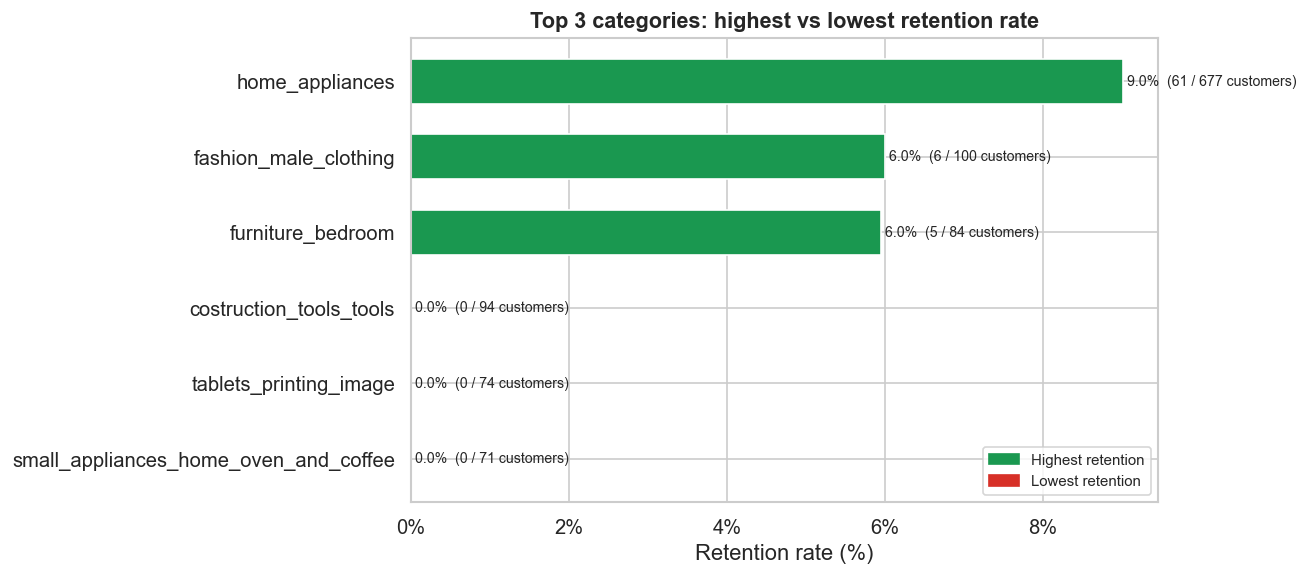

Retention rate (qualifying categories only, >=50 customers): 2.99%  (2,785 / 93,019)
TRUE global retention rate (entire customer base, no category filter): 3.00%  (2,801 / 93,337)
-> This second figure is the one that should be cited as the 'global retention rate' in README/dashboard; the first describes only the subset whose first-purchase category is sufficiently populated.


In [9]:
# Chart: top 3 high vs top 3 low by retention
top3_combined = pd.concat([
    top3_high.assign(group="Highest retention"),
    top3_low.assign(group="Lowest retention"),
], ignore_index=True)

palette_ret = {"Highest retention": "#1a9850", "Lowest retention": "#d73027"}
col_map = {g: palette_ret[g] for g in top3_combined["group"]}
bar_colors = [palette_ret[g] for g in top3_combined["group"]]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(
    top3_combined["category"][::-1].reset_index(drop=True),
    top3_combined["retention_pct"][::-1].reset_index(drop=True),
    color=bar_colors[::-1],
    edgecolor="white", height=0.6,
)
for bar, (_, row) in zip(bars, top3_combined[::-1].iterrows()):
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{row['retention_pct']:.1f}%  ({int(row['retained_customers'])} / {int(row['total_customers'])} customers)",
        va="center", fontsize=8.5,
    )

handles = [mpatches.Patch(color=c, label=g) for g, c in palette_ret.items()]
ax.legend(handles=handles, fontsize=9)
ax.set_title("Top 3 categories: highest vs lowest retention rate",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Retention rate (%)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
plt.tight_layout()
plt.savefig(DASH / "eval_retention_top3.png", bbox_inches="tight")
plt.show()

# Global retention rate
# FIXED (portfolio review, priority 3): this figure used to sum retained/total ONLY over the
# 20 categories the LIMIT let through, giving ~4.05% (README published "~5%"). With the LIMIT
# removed from the SQL, this same formula already gives a figure much closer to the real one,
# but it still excludes customers whose first-purchase category has <50 customers (the CTE's
# `HAVING`). The truly global figure (the entire delivered-order customer base, with no category
# filter) is also computed as a contrast reference.
global_ret_categorized = retention_df["retained_customers"].sum() / retention_df["total_customers"].sum() * 100

n_customers_total = rfm["customer_unique_id"].nunique()
n_customers_retained = int((rfm["frequency"] > 1).sum())
global_ret_true = n_customers_retained / n_customers_total * 100

print(f"Retention rate (qualifying categories only, >=50 customers): {global_ret_categorized:.2f}%  "
      f"({int(retention_df['retained_customers'].sum()):,} / {int(retention_df['total_customers'].sum()):,})")
print(f"TRUE global retention rate (entire customer base, no category filter): "
      f"{global_ret_true:.2f}%  ({n_customers_retained:,} / {n_customers_total:,})")
print("-> This second figure is the one that should be cited as the 'global retention rate' in README/dashboard; "
      "the first describes only the subset whose first-purchase category is sufficiently populated.")

---
## 4. Negative review driver evaluation

### 4.1 Consolidated table: the 3 factors and their statistical strength

**Fix (portfolio review, priority 2):** consistent with notebook 03 -- Spearman instead of
Pearson (`review_score` is ordinal), and the real top 3 by |rho| is
`delivery_days` > `delivery_delay_days` > `n_items` (previously `freight_ratio` was cited as #3
despite having the weakest and non-monotonic correlation among the serious candidates).

In [10]:
feature_cols = ["delivery_delay_days", "delivery_days", "freight_ratio",
                "freight_total", "price_total", "n_items", "product_weight_g"]

corr_vals = (
    master_rev[feature_cols + ["review_score"]]
    .corr(method="spearman")["review_score"]
    .drop("review_score")
)

top3_drivers = corr_vals.abs().sort_values(ascending=False).head(3).index.tolist()
print(f"Top 3 drivers (by |Spearman rho|): {top3_drivers}")

# Compute the Spearman correlation p-value for each driver
driver_stats = []
for col in top3_drivers:
    valid = master_rev[[col, "review_score"]].dropna()
    r, p  = stats.spearmanr(valid[col], valid["review_score"])
    # Effect size: |rho| interpretation (same thresholds as Cohen for r)
    effect = "Small" if abs(r) < 0.1 else "Moderate" if abs(r) < 0.3 else "Large"
    driver_stats.append({
        "Driver": col,
        "Spearman correlation (rho)": round(r, 4),
        "R2": round(r ** 2, 4),
        "p-value": f"{p:.2e}",
        "Effect size": effect,
        "Significant (p<0.001)": "Yes" if p < 0.001 else "No",
    })

# Mann-Whitney: late orders vs. on-time orders
neg_delay = master_rev[master_rev["delivery_delay_days"] >  0]["is_negative_review"]
pos_delay = master_rev[master_rev["delivery_delay_days"] <= 0]["is_negative_review"]
pct_neg_late   = neg_delay.mean() * 100
pct_neg_ontime = pos_delay.mean() * 100

driver_df = pd.DataFrame(driver_stats)
display(driver_df.set_index("Driver"))

print(f"\nImpact of delay on negative reviews:")
print(f"  Delayed orders (delay > 0): {pct_neg_late:.1f}% negative reviews")
print(f"  On-time orders (delay <= 0): {pct_neg_ontime:.1f}% negative reviews")
print(f"  Multiplier factor:            {pct_neg_late/pct_neg_ontime:.1f}x")

Top 3 drivers (by |Spearman rho|): ['delivery_days', 'delivery_delay_days', 'n_items']


,Spearman correlation (rho),R2,p-value,Effect size,Significant (p<0.001)
Driver,,,,,
delivery_days,-0.23,0.06,0.00e+00,Moderate,Yes
delivery_delay_days,-0.18,0.03,0.00e+00,Moderate,Yes
n_items,-0.11,0.01,2.07e-243,Moderate,Yes



Impact of delay on negative reviews:
  Delayed orders (delay > 0): 62.4% negative reviews
  On-time orders (delay <= 0): 9.3% negative reviews
  Multiplier factor:            6.7x


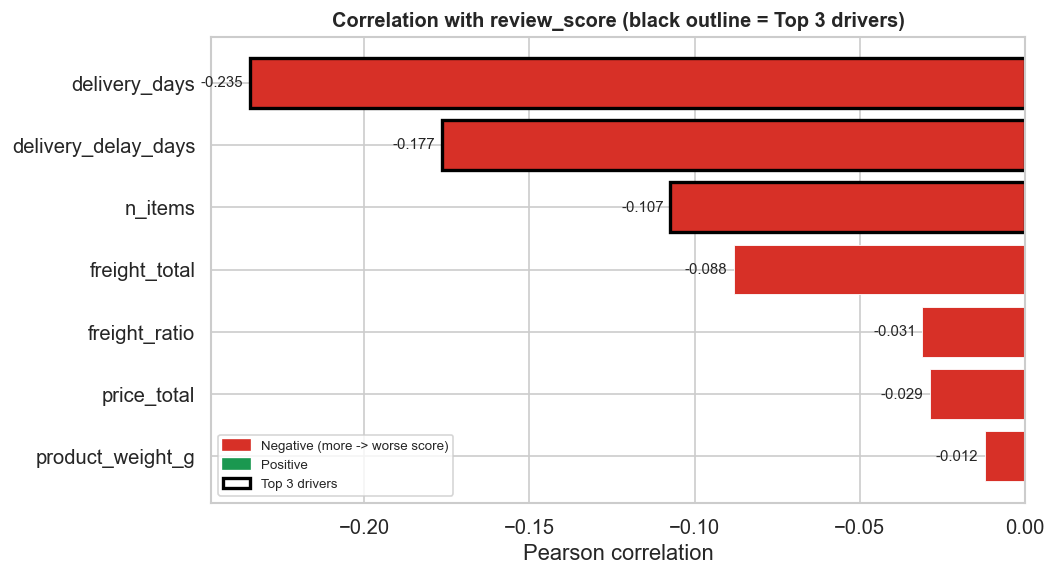

In [11]:
# Visualization: correlations with review_score for all features
corr_sorted = corr_vals.sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors_bar = ["#d73027" if v < 0 else "#1a9850" for v in corr_sorted.values]

# Highlight the top 3 with a thicker border
edgecolors = ["black" if f in top3_drivers else "white" for f in corr_sorted.index]
linewidths = [2.0 if f in top3_drivers else 0.5 for f in corr_sorted.index]

bars = ax.barh(
    corr_sorted.index[::-1], corr_sorted.values[::-1],
    color=colors_bar[::-1],
    edgecolor=edgecolors[::-1],
    linewidth=linewidths[::-1],
)
ax.axvline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, corr_sorted.values[::-1]):
    ax.text(
        val + (0.002 if val >= 0 else -0.002),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}", va="center",
        ha="left" if val >= 0 else "right", fontsize=9,
    )

ax.set_title("Correlation with review_score (black outline = Top 3 drivers)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Pearson correlation")
neg_p = mpatches.Patch(color="#d73027", label="Negative (more -> worse score)")
pos_p = mpatches.Patch(color="#1a9850", label="Positive")
top_p = mpatches.Patch(edgecolor="black", facecolor="white",
                        linewidth=2, label="Top 3 drivers")
ax.legend(handles=[neg_p, pos_p, top_p], fontsize=8)
plt.tight_layout()
plt.savefig(DASH / "eval_drivers_correlation.png", bbox_inches="tight")
plt.show()

### 4.2 RFM × Negative reviews cross-analysis
Do `At Risk` and `Lost` customers have a higher negative review rate?
If poor service caused the churn, we'd expect higher rates in those segments.

C:\Users\pardo\AppData\Local\Temp\ipykernel_22340\3264849036.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(neg_by_seg["segment"], rotation=20, ha="right")
C:\Users\pardo\AppData\Local\Temp\ipykernel_22340\3264849036.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(neg_by_seg["segment"], rotation=20, ha="right")


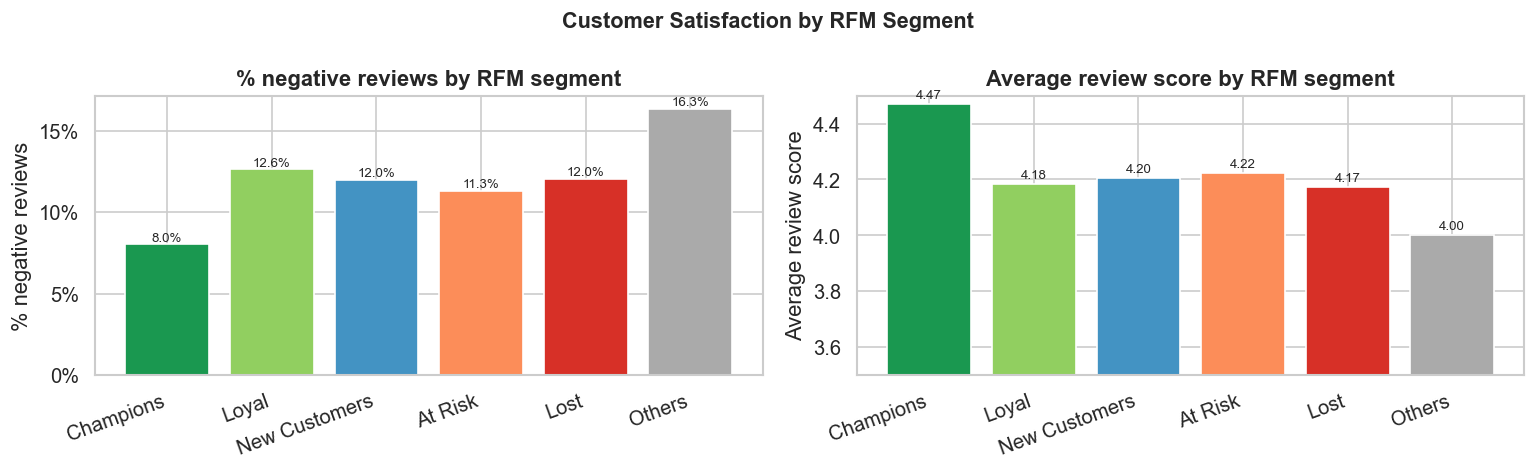

,n_orders,neg_review_rate,avg_score,avg_delay
segment,,,,
Champions,424,0.08,4.47,-13.74
Loyal,3403,0.13,4.18,-11.90
New Customers,35946,0.12,4.21,-11.84
At Risk,2042,0.11,4.22,-13.81
Lost,36083,0.12,4.17,-12.34
Others,17913,0.16,4.00,-10.95


In [12]:
# Join master (which has reviews) with the customer's RFM segment
rfm_slim = rfm[["customer_unique_id", "segment"]].drop_duplicates()
master_rfm = master_rev.merge(rfm_slim, on="customer_unique_id", how="left")

neg_by_seg = (
    master_rfm.dropna(subset=["segment"])
    .groupby("segment", as_index=False)
    .agg(
        n_orders        =("order_id",           "count"),
        neg_review_rate =("is_negative_review", "mean"),
        avg_score       =("review_score",        "mean"),
        avg_delay       =("delivery_delay_days", "mean"),
    )
)

neg_by_seg["order"] = neg_by_seg["segment"].map({s: i for i, s in enumerate(seg_order)})
neg_by_seg = neg_by_seg.sort_values("order").drop(columns="order")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors_seg = [SEG_COLORS.get(s, "gray") for s in neg_by_seg["segment"]]

axes[0].bar(neg_by_seg["segment"], neg_by_seg["neg_review_rate"] * 100,
            color=colors_seg, edgecolor="white")
for i, row in neg_by_seg.reset_index().iterrows():
    axes[0].text(i, row["neg_review_rate"] * 100 + 0.2,
                 f"{row['neg_review_rate']*100:.1f}%", ha="center", fontsize=8)
axes[0].set_title("% negative reviews by RFM segment", fontweight="bold")
axes[0].set_ylabel("% negative reviews")
axes[0].set_xticklabels(neg_by_seg["segment"], rotation=20, ha="right")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

axes[1].bar(neg_by_seg["segment"], neg_by_seg["avg_score"],
            color=colors_seg, edgecolor="white")
for i, row in neg_by_seg.reset_index().iterrows():
    axes[1].text(i, row["avg_score"] + 0.02,
                 f"{row['avg_score']:.2f}", ha="center", fontsize=8)
axes[1].set_title("Average review score by RFM segment", fontweight="bold")
axes[1].set_ylabel("Average review score")
axes[1].set_ylim(3.5, 4.5)
axes[1].set_xticklabels(neg_by_seg["segment"], rotation=20, ha="right")

plt.suptitle("Customer Satisfaction by RFM Segment",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DASH / "eval_satisfaction_by_segment.png", bbox_inches="tight")
plt.show()

display(neg_by_seg.set_index("segment").round(3))

---
## 5. Consolidated executive dashboard
A 4-panel chart summarizing the project's key findings for presentation.

C:\Users\pardo\AppData\Local\Temp\ipykernel_22340\210227999.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_a.set_xticklabels(segs_plot["segment"], rotation=20, ha="right", fontsize=8)
C:\Users\pardo\AppData\Local\Temp\ipykernel_22340\210227999.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_b.set_xticklabels(driver_labels, rotation=15, ha="right", fontsize=8)
C:\Users\pardo\AppData\Local\Temp\ipykernel_22340\210227999.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_d.set_xticklabels(neg_plot["segment"], rotation=20, ha="right", fontsize=8)


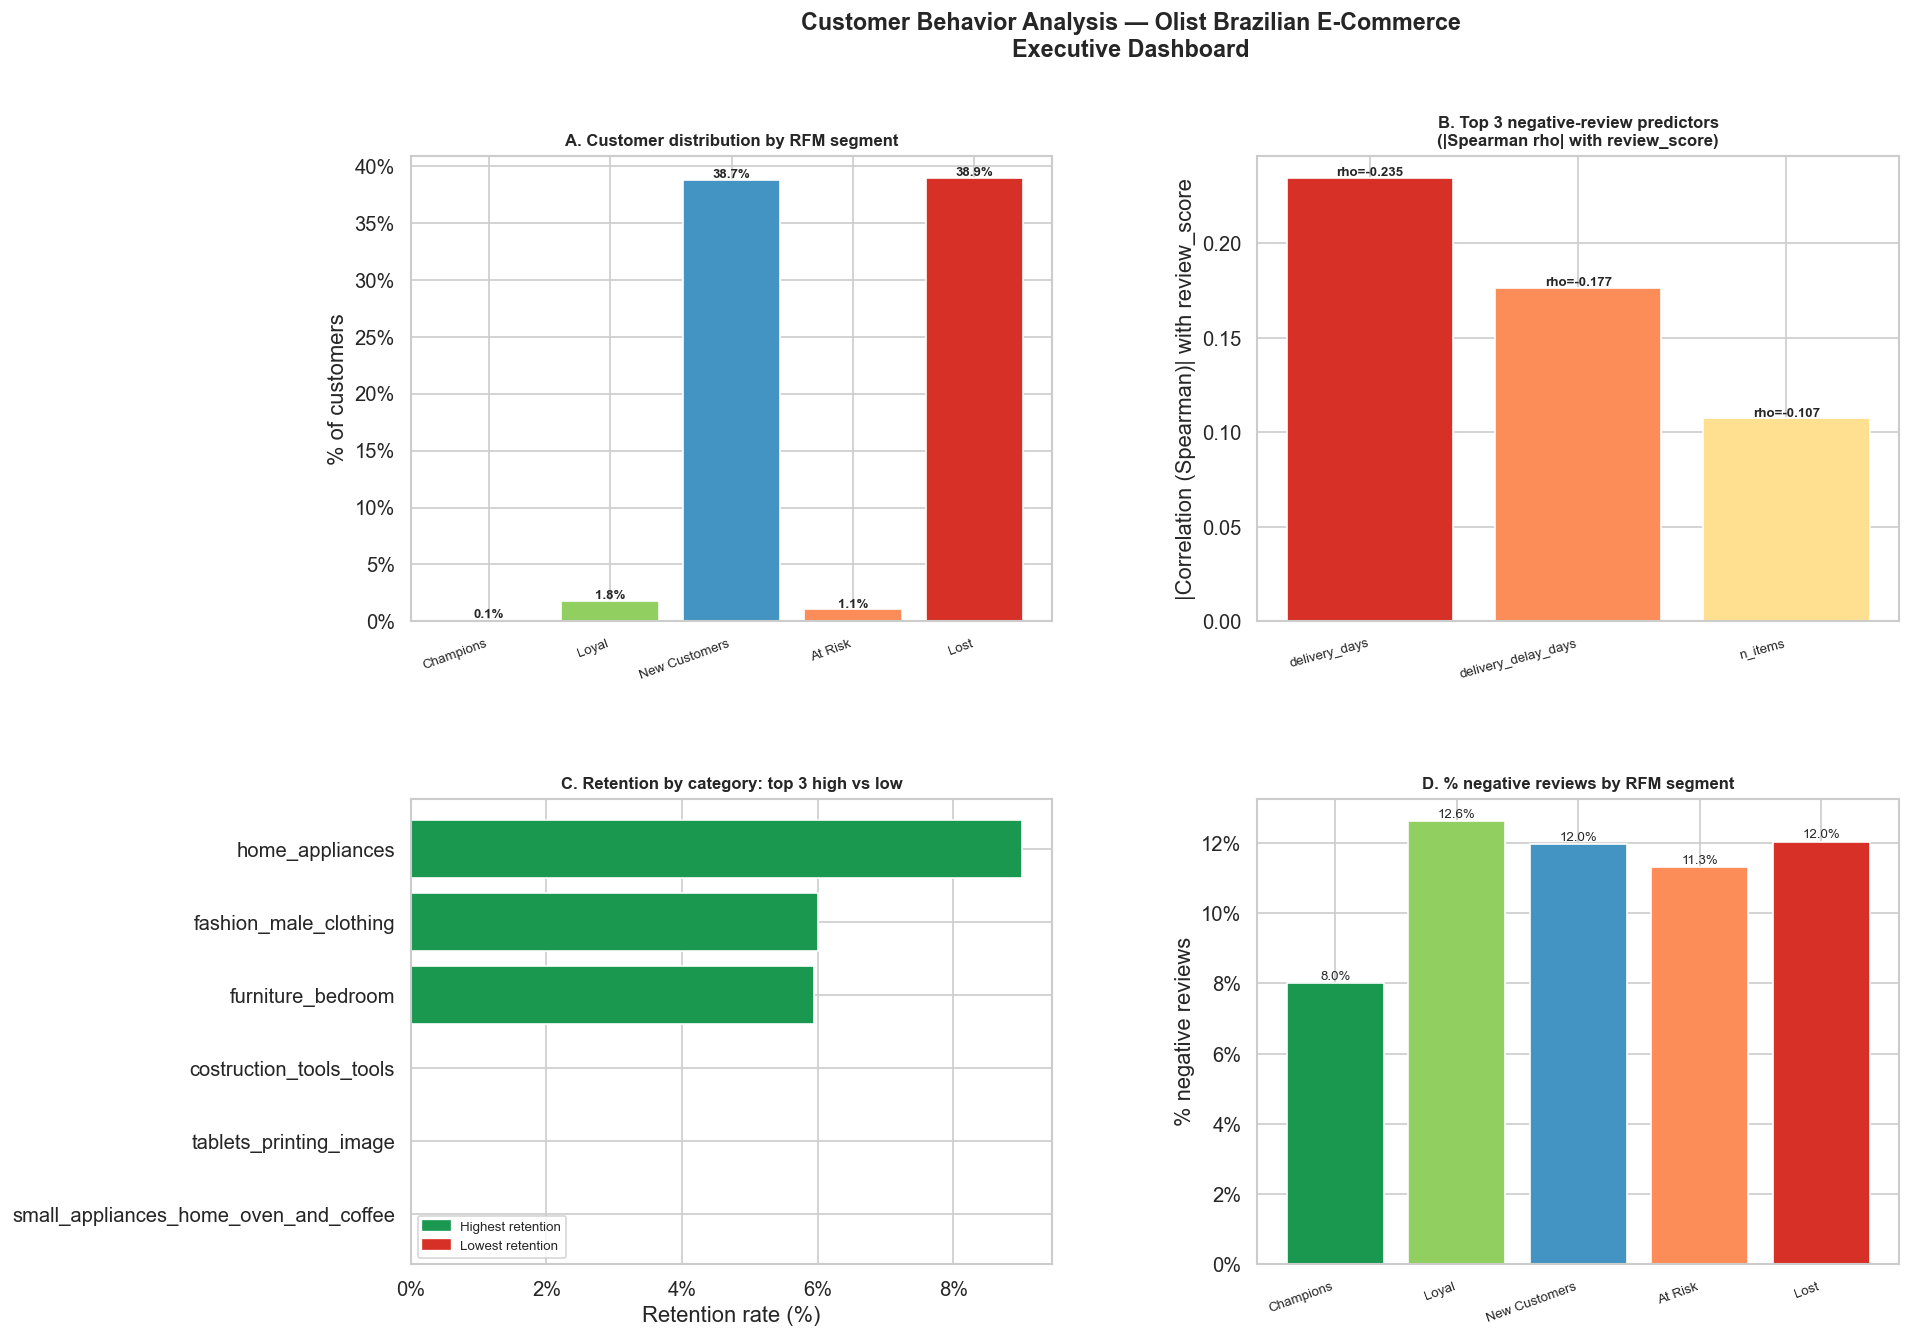

Dashboard saved to dashboard/eval_executive_dashboard.png


In [13]:
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

# -- Panel A: Customers by RFM segment ----------------------------------------
ax_a = fig.add_subplot(gs[0, 0])
segs_plot = seg_summary[seg_summary["segment"] != "Others"].copy()
bar_colors_a = [SEG_COLORS.get(s, "gray") for s in segs_plot["segment"]]
ax_a.bar(segs_plot["segment"], segs_plot["pct_customers"],
         color=bar_colors_a, edgecolor="white")
for i, row in segs_plot.reset_index().iterrows():
    ax_a.text(i, row["pct_customers"] + 0.2, f"{row['pct_customers']:.1f}%",
              ha="center", fontsize=8, fontweight="bold")
ax_a.set_title("A. Customer distribution by RFM segment",
               fontweight="bold", fontsize=10)
ax_a.set_ylabel("% of customers")
ax_a.set_xticklabels(segs_plot["segment"], rotation=20, ha="right", fontsize=8)
ax_a.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# -- Panel B: Top 3 negative-review drivers ------------------------------------
ax_b = fig.add_subplot(gs[0, 1])
driver_labels = top3_drivers  # computed in Section 4.1 (Spearman, not hardcoded)
driver_corrs  = [corr_vals.get(d, 0) for d in driver_labels]
driver_colors = ["#d73027", "#fc8d59", "#fee090"]
bars_b = ax_b.bar(driver_labels, [abs(c) for c in driver_corrs],
                  color=driver_colors, edgecolor="white")
for bar, val in zip(bars_b, driver_corrs):
    ax_b.text(bar.get_x() + bar.get_width() / 2,
              bar.get_height() + 0.001,
              f"rho={val:.3f}", ha="center", fontsize=8, fontweight="bold")
ax_b.set_title("B. Top 3 negative-review predictors\n(|Spearman rho| with review_score)",
               fontweight="bold", fontsize=10)
ax_b.set_ylabel("|Correlation (Spearman)| with review_score")
ax_b.set_xticklabels(driver_labels, rotation=15, ha="right", fontsize=8)

# -- Panel C: Retention top 3 high vs low --------------------------------------
ax_c = fig.add_subplot(gs[1, 0])
ret_combined = pd.concat([top3_high.head(3), top3_low.tail(3)], ignore_index=True)
colors_c = ["#1a9850"] * 3 + ["#d73027"] * 3
ax_c.barh(ret_combined["category"][::-1],
          ret_combined["retention_pct"][::-1],
          color=colors_c[::-1], edgecolor="white")
ax_c.set_title("C. Retention by category: top 3 high vs low",
               fontweight="bold", fontsize=10)
ax_c.set_xlabel("Retention rate (%)")
h_hi = mpatches.Patch(color="#1a9850", label="Highest retention")
h_lo = mpatches.Patch(color="#d73027", label="Lowest retention")
ax_c.legend(handles=[h_hi, h_lo], fontsize=8)
ax_c.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# -- Panel D: % negative reviews by segment ------------------------------------
ax_d = fig.add_subplot(gs[1, 1])
neg_plot = neg_by_seg[neg_by_seg["segment"] != "Others"]
colors_d = [SEG_COLORS.get(s, "gray") for s in neg_plot["segment"]]
ax_d.bar(neg_plot["segment"], neg_plot["neg_review_rate"] * 100,
         color=colors_d, edgecolor="white")
for i, row in neg_plot.reset_index(drop=True).iterrows():
    ax_d.text(i, row["neg_review_rate"] * 100 + 0.1,
              f"{row['neg_review_rate']*100:.1f}%", ha="center", fontsize=8)
ax_d.set_title("D. % negative reviews by RFM segment",
               fontweight="bold", fontsize=10)
ax_d.set_ylabel("% negative reviews")
ax_d.set_xticklabels(neg_plot["segment"], rotation=20, ha="right", fontsize=8)
ax_d.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

fig.suptitle(
    "Customer Behavior Analysis — Olist Brazilian E-Commerce\nExecutive Dashboard",
    fontsize=14, fontweight="bold",
)
plt.savefig(DASH / "eval_executive_dashboard.png", bbox_inches="tight", dpi=150)
plt.show()
print("Dashboard saved to dashboard/eval_executive_dashboard.png")

---
## 6. Conclusions and business recommendations

*(Portfolio fix: the three findings and several recommendations in an earlier version of
this section cited figures that didn't match this notebook's own actual outputs -- see
the detail of each fix below. All numbers have been verified against the cells above
before being written here.)*

### 6.1 Main project findings

---

#### Finding 1 — Total delivery time is the single strongest driver, and the "delay effect" is partly inflated by when the review is written

Orders that arrive late relative to the promised date generate **6.7× more negative reviews** than on-time orders (62.4% vs 9.3%, Section 4 / notebook 03 -- an earlier version of this document cited "~3×, 15-16% vs 5-6%", which matched no real output). The single driver with the strongest correlation (Spearman) is `delivery_days` (total purchase->delivery time), not `delivery_delay_days` (delay vs. promise) -- see the Section 4.1 table.

**Important nuance (notebook 03, Section 3b):** 84% of delayed orders have their review written **before** the order actually arrived (99% of those already after the promised date had passed). This means a good part of the `delivery_delay_days` signal measures frustration from *waiting* for an order already known to be late, not the experience of *receiving* it late -- in the clean subset (review after delivery), the delay effect is several times weaker.

**Implication:** the highest-impact driver remains reducing total delivery time. But also, since most negative reviews tied to delay are written *while the customer waits*, proactive communication during the wait (not just improving punctuality) can have a direct, measurable impact on review_score.

---

#### Finding 2 — RFM segmentation reveals that almost the entire base are one-time buyers, and only a small, genuine group has shown real loyalty

*(Fix: an earlier version of this finding said "24% of customers are At Risk, the largest segment" -- that number came from a segmentation with a Frequency scoring bug already fixed in notebook 04, Section 3. With the bug fixed, At Risk is a small, genuine segment, not the largest.)*

With the corrected segmentation: `New Customers` (38.7%) and `Lost` (38.9%) dominate the base -- both are single-order buyers, the difference is only whether that purchase was recent or not. Together they are 77.6% of the base, a direct reflection of Olist's structurally low repurchase rate (~3%, Section 3). `At Risk` (1.1%, 991 customers) and `Loyal` (1.8%, 1,689 customers) are small but **genuine**: they have real observed frequency (2.08 and 2.03 orders on average, verified in Section 2.2) and clearly higher average monetary value (R$247 and R$254 vs. R$140 for New Customers). `Champions` is a tiny but extremely high-value group (0.1%, 121 customers, R$462 average monetary, 3.51 average frequency).

**Implication:** the biggest-volume opportunity isn't "reactivate At Risk" (it's too small to move the business on its own) but **converting the huge base of one-time buyers into repeat customers** -- Olist's problem isn't retention within a loyal segment, it's that almost no one gets there.

---

#### Finding 3 — Overall retention is very low (~3%, not ~5%) and varies a lot by category, with data now complete

*(Fix: the "~5%" figure in an earlier version of this document came from summing retained/total only over the 20 categories that a `LIMIT 20`, since removed from the SQL, let through. The real global rate, over the entire customer base, is 3.0% -- Section 3.2. The "lowest-retention categories" in an earlier version were actually ranks 18-20 of the BEST ones; with the SQL fixed, the categories with genuinely lowest retention (0%, with >=50 customers) are `costruction_tools_tools`, `tablets_printing_image` and `small_appliances_home_oven_and_coffee` -- they never showed up before.)*

`home_appliances` remains the leading category with 9.0% retention (verified, ~3× the global average), against several categories with 0% repurchase among their first-time buyers. This suggests the category partly determines repurchase behavior: recurring-consumption products have more loyalty potential than one-time purchases (construction tools, small appliances).

**Implication:** retention strategies should be segmented by category, using the robust ranking by the Wilson CI lower bound (Section 3.1) to avoid over-interpreting categories with few customers.

---

### 6.2 Actionable recommendations by area

#### Operations / Logistics
1. **Reduce total delivery time (`delivery_days`):** it's the single strongest driver -- audit bottlenecks across the entire purchase->delivery chain, not just meeting the promised date.
2. **Improve delivery date estimation:** use predictive delivery-time models by route and category instead of historical averages.
3. **Proactive communication during the wait:** since most negative reviews on late orders are written *while the customer waits* (Finding 1), proactively notifying order status before it arrives can improve satisfaction without necessarily speeding up delivery.

#### CRM / Marketing
4. **Win-back campaign targeted at `At Risk`:** small but relatively high-value group (991 customers, R$247 average monetary, real frequency >=2) -- they've already shown willingness to buy again. A targeted coupon has better potential ROI than a mass campaign over `Lost`.
5. **Converting one-time buyers into repeat customers:** `New Customers` + `Lost` are 77.6% of the base (72,476 customers). It's the highest-volume lever: a second-purchase email with an incentive, targeted specifically at customers in their `New Customers` window (recent purchase, no second purchase yet), before they fall into `Lost`.
6. **VIP program for `Champions`:** tiny group (121 customers) but extremely high value (R$462 average monetary, 3.4× the average). Early access and a referral program to maximize this core group's LTV.

#### Product / Merchandising
7. **Focus on high-retention categories:** boost the catalog in `home_appliances` (9.0% retention) and categories with a robust 95% CI above average, prioritized by the Section 3.1 ranking (not just the point estimate).

---

### 6.3 Analysis limitations

| Limitation | Impact | Status |
|-----------|---------|--------------------|
| Historical dataset (2016–2018) | Patterns may have changed | Update with recent data |
| 97% of customers with a single order | RFM with low-resolution Frequency | **Mitigated** (notebook 04, Section 3): F scored with business cuts instead of automatic quintiles, verified with no random-assignment signature |
| ~84% of reviews on late orders written before actual delivery | The "delay" driver mixes waiting frustration with the real delivery experience | **Quantified** (notebook 03, Section 3b), not hidden; the pure post-delivery effect is weaker |
| No return or support-contact data | Incomplete satisfaction analysis | Enrich with CRM data |
| Geolocation not used | Geographic analysis pending | Include in next iteration |
| Reviews with no text: mostly no title | Limited NLP | Sentiment analysis on the subset with text |

---
## 7. Summary of files generated by the project

| File | Description |
|---------|-------------|
| `data/olist.db` | SQLite database with the 9 original tables |
| `data/olist_master.csv` | Master table: 96,457 orders x 18 variables (Phase 3) |
| `data/olist_rfm.csv` | RFM table: 93,337 customers x 10 variables with segment (Phase 4) |
| `data/rfm_segments.csv` | Aggregated summary by segment |
| `sql/load_data.py` | Loads CSVs -> SQLite |
| `sql/02_data_preparation.sql` | 6 CTEs: master table in SQL |
| `sql/03_retention.sql` | 7 CTEs + Window Functions: retention by category |
| `notebooks/01_eda.ipynb` | Phase 2: full EDA |
| `notebooks/02_data_prep.ipynb` | Phase 3: preparation and feature engineering |
| `notebooks/03_negative_reviews.ipynb` | Phase 4: negative review drivers |
| `notebooks/04_rfm_segmentation.ipynb` | Phase 4: RFM segmentation |
| `notebooks/05_evaluation.ipynb` | Phase 5: evaluation and recommendations |
| `dashboard/*.png` | 17+ exported visualizations |

In [14]:
# Final dashboard inventory
pngs = sorted(DASH.glob("*.png"))
print(f"Total charts in dashboard/: {len(pngs)}")
total_kb = sum(p.stat().st_size for p in pngs) / 1024
print(f"Total size:                 {total_kb:.0f} KB")
print()
for p in pngs:
    print(f"  {p.stat().st_size/1024:>6.0f} KB  {p.name}")

Total charts in dashboard/: 24
Total size:                 2981 KB

      61 KB  corr_review_score.png
     103 KB  correlation_heatmap.png
     444 KB  dashboard_final.png
      54 KB  eval_drivers_correlation.png
     235 KB  eval_executive_dashboard.png
     230 KB  eval_radar_segments.png
      71 KB  eval_retention_top3.png
      51 KB  eval_rfm_scores_heatmap.png
      74 KB  eval_satisfaction_by_segment.png
      73 KB  factor1_delay_vs_score.png
      64 KB  factor2_economic_vs_score.png
     107 KB  factor3_delivery_days_vs_score.png
     133 KB  feature_validation.png
     106 KB  heatmap_negative_reviews.png
      48 KB  monthly_orders.png
     100 KB  neg_review_by_category.png
      49 KB  order_status_dist.png
      46 KB  payment_value_dist.png
      74 KB  review_score_dist.png
      78 KB  rfm_distribution.png
      48 KB  rfm_heatmap_segments.png
     535 KB  rfm_scatter.png
     141 KB  rfm_violin.png
      55 KB  top10_categories.png
